# Positronic Brain v3 — Inference Demo

This notebook demonstrates loading a trained (or fresh) PositronicBrain, running forward passes with different multi-modal zone input patterns, inspecting firing-rate traces, and visualizing zone dynamics.

The v3 brain has **sparse, learnable synapses** (conductance-based dynamics, Dale's law E/I balance) and **configurable multi-modal zones** (Visual, Auditory, Somatosensory, Memory, Emotion, Association). It supports optional Metal (MPS) acceleration on Apple Silicon via `device="auto"`. The high-level API `run_with_inputs(vec)` returns plain numpy arrays.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Make sure we can import the package when running from examples/
sys.path.insert(0, str(Path.cwd().parent))

from positronic_brain.model import PositronicBrain, BrainConfig
from positronic_brain.zones import DEFAULT_ZONES, get_zone_info


## Load or create model

In [2]:
model_path = Path("../trained_models/positronic_brain_v2.pt")

if model_path.exists():
    brain = PositronicBrain.load(str(model_path), device="auto", strict=False)
    print("Loaded trained model")
else:
    cfg = BrainConfig(grid_size=4, recurrent_steps=12, seed=42)
    brain = PositronicBrain(cfg, device="auto")
    brain.eval()
    print("Using fresh (untrained) model")

# Helper: build a (Z,) input vector from a {zone_name: value} mapping
NAMES = brain.config.zone_names
COLORS = {z.name: z.color for z in DEFAULT_ZONES}
ZONE_COLORS = [COLORS.get(nm, "#9CA3AF") for nm in NAMES]

def make_input(**kwargs):
    vec = np.zeros(len(NAMES), dtype=np.float32)
    for nm, val in kwargs.items():
        if nm in NAMES:
            vec[NAMES.index(nm)] = val
    return vec

print(f"Neurons: {brain.num_neurons} | Synapses: {brain.num_edges} | Steps: {brain.config.recurrent_steps}")
print(f"Zones: {NAMES}")
print(f"Inhibitory neurons: {int(brain.is_inhibitory.sum())}/{brain.num_neurons}")
print(f"Device: {brain.device}")


Loaded trained model
Neurons: 64 | Synapses: 1024 | Steps: 12
Zones: ['Visual', 'Auditory', 'Somatosensory', 'Memory', 'Emotion', 'Association']
Inhibitory neurons: 13/64
Device: mps:0


## Device / GPU note (Apple Silicon MacBook Pro)

In [3]:
# The model supports Metal (MPS) on Apple Silicon.
# device="auto" (or "mps") will use the GPU when available.
# Results from run_with_inputs() are plain numpy arrays.

print("brain.device =", brain.device)
test = brain.run_with_inputs(make_input(Visual=0.4, Auditory=0.3, Memory=0.2))
print("  type of trace:", type(test["trace"]), "shape:", test["trace"].shape)  # (T+1, B, N)
print("  output (numpy):", test["output"])


brain.device = mps:0


  type of trace: <class 'numpy.ndarray'> shape: (13, 1, 64)
  output (numpy): [0.33669698]


## Run several interesting input regimes

In [4]:
scenarios = {
    "Threat (visual + auditory)": make_input(Visual=0.92, Auditory=0.87, Emotion=0.5),
    "Calm memory recall": make_input(Memory=0.94),
    "Painful touch + emotion": make_input(Somatosensory=0.9, Emotion=0.85),
    "Cross-modal integration": make_input(Visual=0.62, Auditory=0.58, Association=0.76),
    "Baseline low activity": make_input(),
}

results = {}
for name, vec in scenarios.items():
    res = brain.run_with_inputs(vec)
    results[name] = res
    print(f"{name:30s} -> output = {float(res['output'].ravel()[0]):.4f}  "
          f"mean rate = {res['rates'].mean():.3f}")


Threat (visual + auditory)     -> output = 0.7161  mean rate = 0.298
Calm memory recall             -> output = 0.2718  mean rate = 0.129
Painful touch + emotion        -> output = 0.4851  mean rate = 0.299


Cross-modal integration        -> output = 0.6661  mean rate = 0.246
Baseline low activity          -> output = 0.1710  mean rate = 0.075


## Plot zone activation trajectories

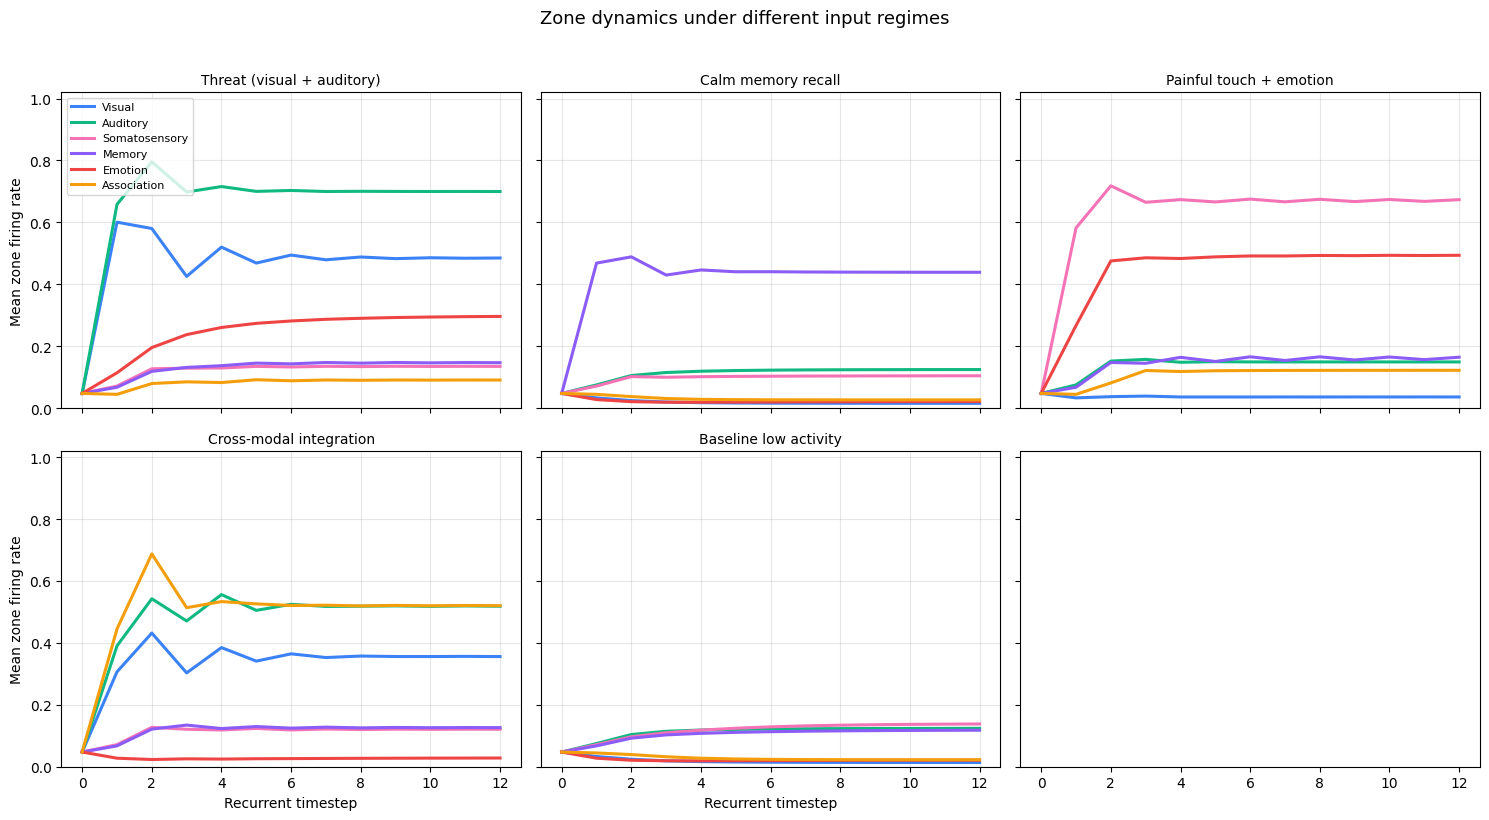

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    trace = res["trace"][:, 0, :]   # (T+1, N)
    zones = res["zones"]
    for zid, zname in enumerate(NAMES):
        mask = zones == zid
        if not np.any(mask):
            continue
        ax.plot(trace[:, mask].mean(axis=1), label=zname, color=ZONE_COLORS[zid], linewidth=2.2)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3)
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("Mean zone firing rate")
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel("Recurrent timestep")

axes[0].legend(loc="upper left", fontsize=8)
plt.suptitle("Zone dynamics under different input regimes", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Final state histogram across scenarios

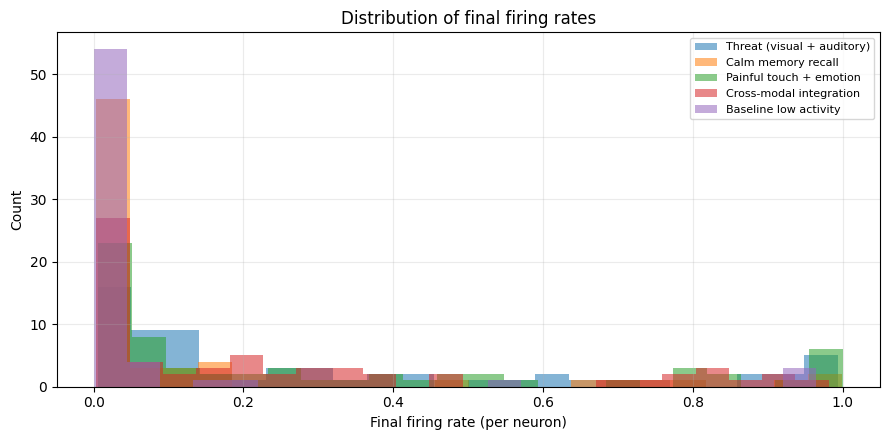

In [6]:
plt.figure(figsize=(9, 4.5))
for name, res in results.items():
    final = res["rates"][0]   # final firing rates per neuron
    plt.hist(final, bins=22, alpha=0.55, label=name, histtype="stepfilled")
plt.xlabel("Final firing rate (per neuron)")
plt.ylabel("Count")
plt.title("Distribution of final firing rates")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## Inspect connectivity properties

Neurons: 64 | Synapses (edges): 1024
Graph density: 25.0% of a dense 64x64 connectome
Excitatory synapses: 476 | Inhibitory synapses: 215
Mean |w| (exc): 0.3372 | mean |w| (inh): 1.0769


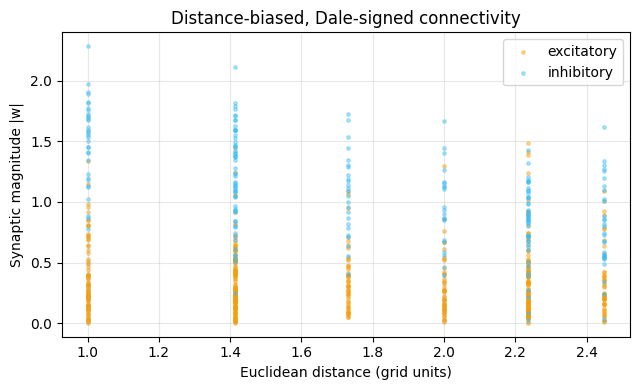

In [7]:
# The connectome is now a sparse graph of learnable, Dale-signed synapses.
ei = brain.edge_index.cpu().numpy()       # (2, E): row 0 = presyn, row 1 = postsyn
w = brain.signed_weights().detach().cpu().numpy()  # (E,) signed by Dale's law
pos = brain.get_neuron_positions()
src, dst = ei[0], ei[1]
edge_dist = np.linalg.norm(pos[src] - pos[dst], axis=1)

dense_equiv = brain.num_neurons ** 2
print(f"Neurons: {brain.num_neurons} | Synapses (edges): {brain.num_edges}")
print(f"Graph density: {100*brain.num_edges/dense_equiv:.1f}% of a dense {brain.num_neurons}x{brain.num_neurons} connectome")
print(f"Excitatory synapses: {(w > 0).sum()} | Inhibitory synapses: {(w < 0).sum()}")
print(f"Mean |w| (exc): {np.abs(w[w>0]).mean():.4f} | mean |w| (inh): {np.abs(w[w<0]).mean():.4f}")

# Distance vs synaptic magnitude, coloured by sign
plt.figure(figsize=(6.5, 4))
exc = w > 0
inh = w < 0
plt.scatter(edge_dist[exc], np.abs(w[exc]), s=6, alpha=0.4, color="#f59e0b", label="excitatory")
plt.scatter(edge_dist[inh], np.abs(w[inh]), s=6, alpha=0.4, color="#38bdf8", label="inhibitory")
plt.xlabel("Euclidean distance (grid units)")
plt.ylabel("Synaptic magnitude |w|")
plt.title("Distance-biased, Dale-signed connectivity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Try a custom input pattern

In [8]:
custom = make_input(Visual=0.4, Memory=0.7, Association=0.55)
res = brain.run_with_inputs(custom)
print("Custom input:", {nm: round(float(custom[i]), 2) for i, nm in enumerate(NAMES) if custom[i] > 0})
print("Output probability:", round(float(res["output"].ravel()[0]), 4))

zones = res["zones"]
zone_means = {nm: round(float(res["rates"][0][zones == i].mean()), 3)
              for i, nm in enumerate(NAMES) if np.any(zones == i)}
print("Final zone means:", zone_means)

# Per-timestep zone means
trace = res["trace"][:, 0, :]
for t in [0, 3, 6, 9, 12]:
    acts = [round(float(trace[t, zones == zid].mean()), 3) for zid in range(len(NAMES)) if np.any(zones == zid)]
    print(f"t={t:2d}  zone_means={acts}")


Custom input: {'Visual': 0.4, 'Memory': 0.7, 'Association': 0.55}
Output probability: 0.3701
Final zone means: {'Visual': 0.219, 'Auditory': 0.149, 'Somatosensory': 0.103, 'Memory': 0.313, 'Emotion': 0.023, 'Association': 0.34}
t= 0  zone_means=[0.047, 0.047, 0.047, 0.047, 0.047, 0.047]
t= 3  zone_means=[0.198, 0.138, 0.1, 0.314, 0.021, 0.342]
t= 6  zone_means=[0.22, 0.149, 0.102, 0.317, 0.022, 0.342]
t= 9  zone_means=[0.219, 0.149, 0.103, 0.314, 0.023, 0.34]
t=12  zone_means=[0.219, 0.149, 0.103, 0.313, 0.023, 0.34]
